In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Because we use colab, when the data is being accessed through google drive. It really slows down the training. So we will copy the data from drive to local

In [2]:
from pathlib import Path
zip_path = "/content/drive/MyDrive/early-fire-detection/zippy/data.zip"
!unzip -o -q {zip_path} -d /

In [3]:
import sys
from pathlib import Path
PROJECT_ROOT = Path("/content/drive/MyDrive/early-fire-detection")
sys.path.insert(0, str(PROJECT_ROOT))

In [21]:
import torch
from torch.utils.data import DataLoader
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
    FasterRCNN_ResNet50_FPN_V2_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib.pyplot as plt

In [5]:
from helpers.utils import set_seed
from helpers.datahelperrr import FireDataset, collate_fn

In [6]:
DATA_DIR = Path("/data")
RUNS = PROJECT_ROOT / "models" / "runs"
NUM_CLASSES = 3  # in torchvision background is always 0

In [7]:
torch.cuda.is_available()

True

In [8]:
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
train_ds = FireDataset(DATA_DIR / "train", augment=False)
loader = DataLoader(train_ds, batch_size=2, shuffle=True, collate_fn=collate_fn)

In [10]:
images, targets = next(iter(loader))

In [11]:
images[0].shape, targets[0]["boxes"].shape, targets[0]["labels"]

(torch.Size([3, 640, 640]), torch.Size([1, 4]), tensor([2]))

We use Faster R-CNN ResNet-50-FPN v2 with COCO pretrained weights. After loading we replace only the box predictor so the head outputs fire and smoke. The backbone and FPN stay pretrained.

In [12]:
def build_fasterrcnn(num_classes = NUM_CLASSES, trainable_backbone_layers = 3):
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1
    model = fasterrcnn_resnet50_fpn_v2(weights=weights, trainable_backbone_layers=trainable_backbone_layers) # Right now head is same as COCO pretrained model. 91 class. It can conflict so we dont give the num classes parameter 
    in_features = model.roi_heads.box_predictor.cls_score.in_features # Read how many features go into old head so new head must use the same width
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes) # new head
    model.transform.min_size = (640,)
    model.transform.max_size = 640
    # lock the model's own resize to 640. We already letterbox to 640×640 so this stops it from resizing the image again.
    return model

In [13]:
model = build_fasterrcnn()
model.to(device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 232MB/s] 


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(640,), max_size=640, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        

In [15]:
model.roi_heads.box_predictor.cls_score.out_features

3

In train mode the model returns a loss dict and in eval mode it returns boxes, labels, and scores. If this cell runs the pipeline is ready for a real training loop

In [16]:
images = [img.to(device) for img in images]
targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

model.train()
loss_dict = model(images, targets)

In [17]:
loss_dict

{'loss_classifier': tensor(1.1585, device='cuda:0', grad_fn=<NllLossBackward0>),
 'loss_box_reg': tensor(0.0295, device='cuda:0', grad_fn=<DivBackward0>),
 'loss_objectness': tensor(0.0609, device='cuda:0',
        grad_fn=<BinaryCrossEntropyWithLogitsBackward0>),
 'loss_rpn_box_reg': tensor(0.0618, device='cuda:0', grad_fn=<DivBackward0>)}

In [18]:
loss_dict.values()

dict_values([tensor(1.1585, device='cuda:0', grad_fn=<NllLossBackward0>), tensor(0.0295, device='cuda:0', grad_fn=<DivBackward0>), tensor(0.0609, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), tensor(0.0618, device='cuda:0', grad_fn=<DivBackward0>)])

In [19]:
model.eval()
with torch.no_grad():
    preds = model(images)
preds[0].keys()

dict_keys(['boxes', 'labels', 'scores'])

In [20]:
len(preds[0]["boxes"])

100

We are ready to train our model. One training epoch. The model returns all four losses we sum them call backward, and step the optimizer. We start with SGD as in the torchvision detection tutorial.

In [14]:
from helpers.utils import make_run_dir, BestCheckpoint, append_metrics

train_ds = FireDataset(DATA_DIR / "train", augment=True)
val_ds = FireDataset(DATA_DIR / "val", augment=False)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, collate_fn=collate_fn, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, collate_fn=collate_fn, num_workers=4, pin_memory=True)

In [ ]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
run_dir = make_run_dir(RUNS, "fasterrcnn_v2_baseline")
ckpt = BestCheckpoint(run_dir)

In [22]:
# model.train()
# n = 0
# running = 0.0

# for images, targets in train_loader:
#     images = [img.to(device) for img in images]
#     targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
#     loss_dict = model(images, targets)
#     loss = sum(loss_dict.values())

#     optimizer.zero_grad() # Clear gradients from previous step
#     loss.backward() # Backpropagate the loss
#     optimizer.step() # Update the model parameters
#     running += loss.item()
#     n += 1
#     if n % 200 == 0:
#         print(n, running / n)

# train_loss = running / n
# print("train_loss", train_loss)

In [23]:
# model.train()
# val_running = 0.0
# val_n = 0

# with torch.no_grad():
#     for images, targets in val_loader:
#         images = [img.to(device) for img in images]
#         targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
#         loss_dict = model(images, targets)
#         loss = sum(loss_dict.values())
#         val_running += loss.item()
#         val_n += 1

# val_loss = val_running / val_n
# val_loss

In [24]:
# ckpt.update(model, optimizer, epoch=1, metric=-val_loss)
# append_metrics(run_dir / "metrics.csv", {
#     "epoch": 1,
#     "train_loss": train_loss,
#     "val_loss": val_loss,
# })

In [ ]:
from helpers.utils import load_checkpoint


START = RUNS / "fasterrcnn_v2_baseline" / "weights" / "last.pt"
START.exists()
if START.exists():
    ckpt_data = load_checkpoint(START, model, optimizer)
    start_epoch = int(ckpt_data["epoch"]) + 1
else:
    start_epoch = 1

True

In [26]:
from helpers.utils import load_checkpoint

ckpt_data = load_checkpoint(START, model, optimizer)
start_epoch = int(ckpt_data["epoch"]) + 1

In [27]:
EPOCHS = 10

for epoch in range(start_epoch, EPOCHS + 1):
    # train the model for one epoch
    model.train()
    n = 0
    running = 0.0
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item()
        n+=1
    train_loss = running / n

    # validate the model on the validation dataset
    val_running = 0.0
    val_n = 0
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())
            val_running += loss.item()
            val_n += 1
    val_loss = val_running / val_n


    # save the model checkpoint and metrics
    ckpt.update(model, optimizer, epoch=epoch, metric=-val_loss) # best score wins in our case we want to minimize the validation loss so we use -val_loss as the metric
    append_metrics(run_dir / "metrics.csv", {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
    })
    print(f"Epoch {epoch}: train_loss={train_loss}, val_loss={val_loss}")

Epoch 2: train_loss=0.11040149080246443, val_loss=0.10611683201113362
Epoch 3: train_loss=0.09791161590942839, val_loss=0.10185291835226895
Epoch 4: train_loss=0.09141636853579616, val_loss=0.10127770736173618
Epoch 5: train_loss=0.08742294797948638, val_loss=0.10236274750411876
Epoch 6: train_loss=0.0837115489450268, val_loss=0.09936717006326454
Epoch 7: train_loss=0.07923593507606352, val_loss=0.09949529893193508
Epoch 8: train_loss=0.07691682527055506, val_loss=0.10083740954201646
Epoch 9: train_loss=0.0745173444757696, val_loss=0.10011771536129384
Epoch 10: train_loss=0.07413102431436543, val_loss=0.10245450014717009


Now we will add this training epoch loop to helpers/utils.py

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(run_dir / "metrics.csv")
df

,epoch,train_loss,val_loss
0,1,0.157693,0.138122
1,2,0.110401,0.106117
2,3,0.097912,0.101853
3,4,0.091416,0.101278
4,5,0.087423,0.102363
5,6,0.083712,0.099367
6,7,0.079236,0.099495
7,8,0.076917,0.100837
8,9,0.074517,0.100118
9,10,0.074131,0.102455


Train loss keeps falling. Val loss bottoms out around epoch 6 and then rises a little. We keep best.pt from that epoch and do not train this baseline longer.

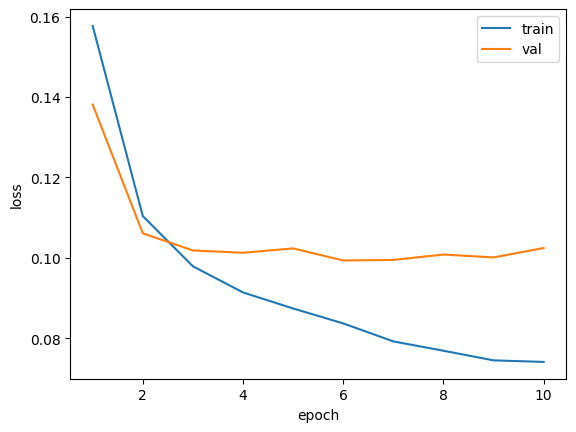

In [29]:
plt.plot(df["epoch"], df["train_loss"], label="train")
plt.plot(df["epoch"], df["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

In [30]:
from helpers.utils import load_checkpoint
load_checkpoint(run_dir / "weights" / "best.pt", model)

{'epoch': 6,
 'metric': -0.09936717006326454,
 'model': OrderedDict([('backbone.body.conv1.weight',
               tensor([[[[-6.1102e-03,  9.5599e-03,  3.1568e-02,  ..., -1.4302e-01,
                           4.7951e-02,  2.8355e-02],
                         [-1.0539e-02, -7.9132e-04,  8.8673e-02,  ..., -3.3262e-01,
                           5.0684e-02,  8.0228e-02],
                         [ 5.8592e-03, -8.4502e-03,  5.4741e-02,  ..., -4.0573e-01,
                          -7.0297e-02,  1.4837e-01],
                         ...,
                         [ 4.2638e-03,  2.5437e-02, -4.4603e-02,  ..., -1.1729e-01,
                          -1.7737e-01,  1.0410e-01],
                         [-1.7198e-03, -6.8754e-04, -1.9032e-02,  ..., -3.7532e-02,
                          -7.5427e-02,  3.8558e-02],
                         [-5.2213e-03, -1.4919e-02, -1.0002e-02,  ..., -2.4140e-02,
                          -3.2910e-02, -2.3537e-03]],
               
                        [[ 1.31

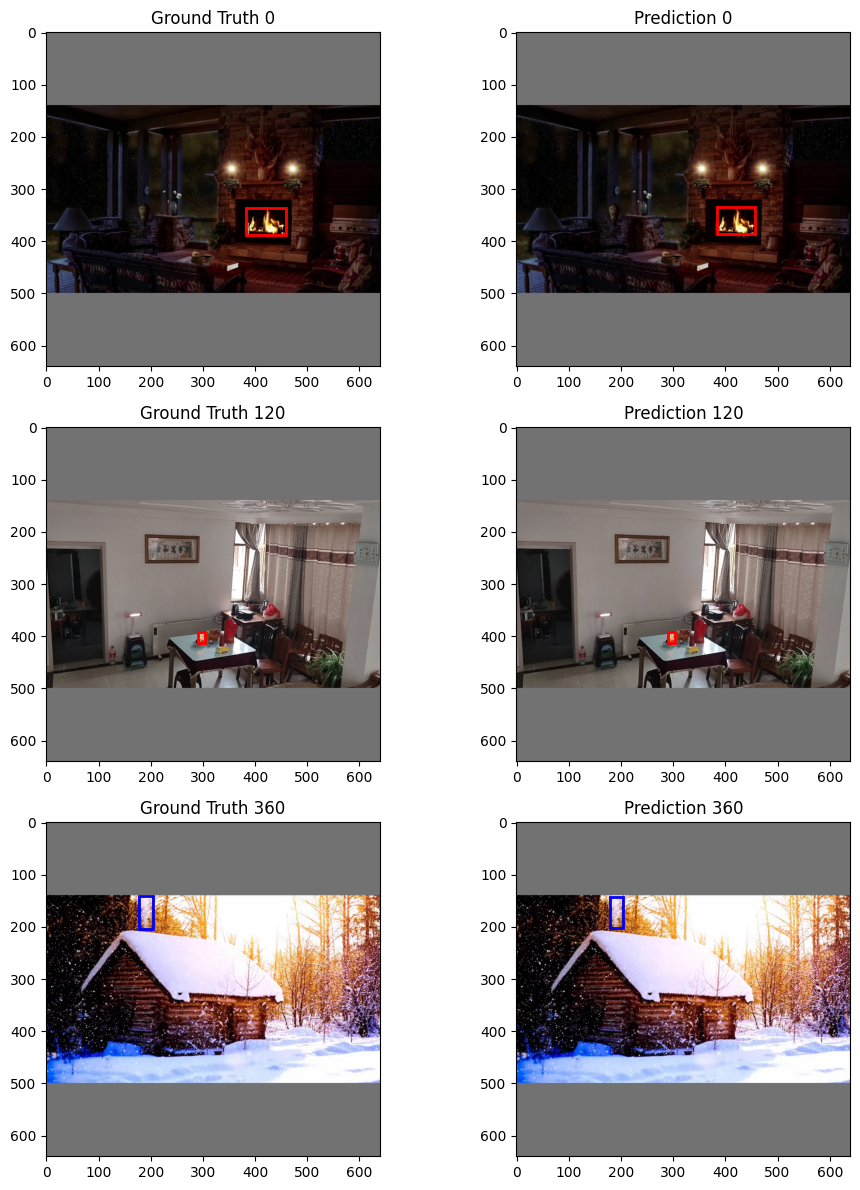

In [36]:
from helpers.viz import draw_xyxy_boxes
model.eval()
idxs = [0, 120, 360]
fig, axes = plt.subplots(len(idxs), 2, figsize=(10, 4 * len(idxs)))

for row, i in enumerate(idxs):
    image, target = val_ds[i]
    with torch.no_grad():
        pred = model([image.to(device)])[0]

    canvas = image.permute(1, 2, 0).cpu().numpy()

    axes[row, 0].imshow(canvas) # left: ground truth
    draw_xyxy_boxes(axes[row, 0], target["boxes"], target["labels"])
    axes[row, 0].set_title(f"Ground Truth {i}")

    axes[row, 1].imshow(canvas) # right: prediction
    draw_xyxy_boxes(axes[row, 1], pred["boxes"].cpu(), pred["labels"].cpu(), scores=pred["scores"].cpu(), conf=0.5) #matplotlib cannot use cuda tensors
    axes[row, 1].set_title(f"Prediction {i}")

plt.tight_layout()
plt.show()

It seems to be working well

In [ ]:
from helpers.utils import (
    set_seed,
    make_run_dir,
    train_detection_run,
    load_checkpoint
)

Freezed run for head fasterrcnn

In [23]:
set_seed(42)
model = build_fasterrcnn(trainable_backbone_layers=0)
model.to(device)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
run_dir = make_run_dir(RUNS, "fasterrcnn_v2_freeze_head")

train_detection_run(
    model, optimizer, train_loader, val_loader, device, run_dir, epochs=5,
)

Epoch 1, Step 200, Loss: 0.27085121724754574
Epoch 1, Step 400, Loss: 0.22731763433665036
Epoch 1 completed. Train Loss: 0.21667544578858575, Val Loss: 0.15667720815521077
Epoch 2, Step 200, Loss: 0.1617444346472621
Epoch 2, Step 400, Loss: 0.15345195269212128
Epoch 2 completed. Train Loss: 0.15203335357555112, Val Loss: 0.14096200059345163
Epoch 3, Step 200, Loss: 0.1415492594987154
Epoch 3, Step 400, Loss: 0.1384821954742074
Epoch 3 completed. Train Loss: 0.13747406677633037, Val Loss: 0.13366319924775807
Epoch 4, Step 200, Loss: 0.12608855022117496
Epoch 4, Step 400, Loss: 0.12886899121105672
Epoch 4 completed. Train Loss: 0.12967252780179508, Val Loss: 0.1258466534453667
Epoch 5, Step 200, Loss: 0.120876558534801
Epoch 5, Step 400, Loss: 0.12321387083269655
Epoch 5 completed. Train Loss: 0.12262213533957962, Val Loss: 0.12102015515320871


Freeze: val_loss 0.157 → 0.121. Train and val fall together, so the new head adapted and we are not overfitting. We keep this best.pt and unfreeze next.

Unfreeze and run

In [26]:
set_seed(42)
model = build_fasterrcnn(trainable_backbone_layers=3)
model.to(device)
load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)
run_dir = make_run_dir(RUNS, "fasterrcnn_v2_unfreeze_l3_lr001")
train_detection_run(
    model, optimizer, train_loader, val_loader, device, run_dir, epochs=5,
)

Epoch 1, Step 200, Loss: 0.10827573904767633
Epoch 1, Step 400, Loss: 0.10827674723230302
Epoch 1 completed. Train Loss: 0.10749209901226349, Val Loss: 0.11470385026072431
Epoch 2, Step 200, Loss: 0.10467996031045913
Epoch 2, Step 400, Loss: 0.1023444065079093
Epoch 2 completed. Train Loss: 0.10217764636226853, Val Loss: 0.1137209845009757
Epoch 3, Step 200, Loss: 0.09775403995066881
Epoch 3, Step 400, Loss: 0.09767427033744752
Epoch 3 completed. Train Loss: 0.09730758592028355, Val Loss: 0.11200968704066394
Epoch 4, Step 200, Loss: 0.0904432812333107
Epoch 4, Step 400, Loss: 0.09238278624601662
Epoch 4 completed. Train Loss: 0.09289294296539709, Val Loss: 0.11199190252763362
Epoch 5, Step 200, Loss: 0.08732053888961673
Epoch 5, Step 400, Loss: 0.08862552049569786
Epoch 5 completed. Train Loss: 0.08869407135901637, Val Loss: 0.11036042574267446


Unfreeze: val_loss 0.115 → 0.110. Still falling, but slower than the freeze phase. Best val is 0.110, worse than the single-stage baseline (0.0994). The unfreeze lr was 5x smaller than the baseline so we cannot blame staging yet

In [25]:
import pandas as pd
runs = [
    "fasterrcnn_v2_baseline",
    "fasterrcnn_v2_freeze_head",
    "fasterrcnn_v2_unfreeze_l3_lr001",
]
rows = []
for name in runs:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    best = df.loc[df["val_loss"].idxmin()]
    rows.append({
        "run": name,
        "epochs": len(df),
        "best_epoch": int(best["epoch"]),
        "train_loss": best["train_loss"],
        "val_loss": best["val_loss"],
    })
results = pd.DataFrame(rows).sort_values("val_loss").reset_index(drop=True)
results

,run,epochs,best_epoch,train_loss,val_loss
0,fasterrcnn_v2_baseline,10,6,0.083712,0.099367
1,fasterrcnn_v2_unfreeze_l3_lr001,5,5,0.088694,0.110360
2,fasterrcnn_v2_freeze_head,5,5,0.122424,0.120694


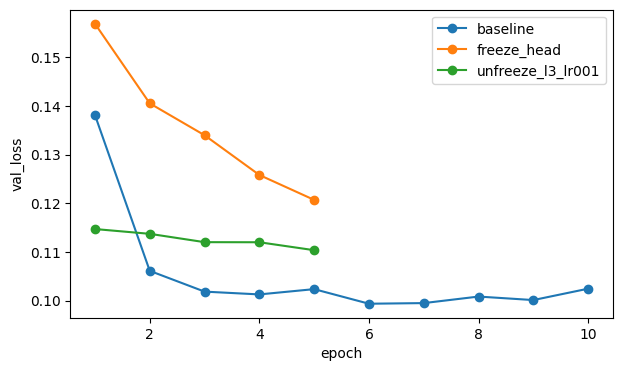

In [26]:
plt.figure(figsize=(7, 4))
for name in runs:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    plt.plot(df["epoch"], df["val_loss"], marker="o", label=name.replace("fasterrcnn_v2_", ""))
plt.xlabel("epoch")
plt.ylabel("val_loss")
plt.legend()
plt.show()

Val loss on the same plot. Baseline is 10 epochs; freeze and unfreeze are 5, so the x-axis is not aligned

Baseline wins and then stays flat. Freeze starts high and falls every epoch. Unfreeze starts from the freeze checkpoint and barely moves. It is still worse than baseline. Next we rerun unfreeze at lr=0.005 so staging and learning rate are not mixed.

In [27]:
set_seed(42)
model = build_fasterrcnn(trainable_backbone_layers=3)
model.to(device)
load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
run_dir = make_run_dir(RUNS, "fasterrcnn_v2_unfreeze_l3_lr005")
train_detection_run(
    model, optimizer, train_loader, val_loader, device, run_dir, epochs=5,
)

Epoch 1, Step 200, Loss: 0.11308179745450615
Epoch 1, Step 400, Loss: 0.1141917079873383
Epoch 1 completed. Train Loss: 0.11334793701706851, Val Loss: 0.11468140316978553
Epoch 2, Step 200, Loss: 0.10462207287549972
Epoch 2, Step 400, Loss: 0.1021508938446641
Epoch 2 completed. Train Loss: 0.10224705526880065, Val Loss: 0.1110861628470611
Epoch 3, Step 200, Loss: 0.0933472541719675
Epoch 3, Step 400, Loss: 0.09425539942458272
Epoch 3 completed. Train Loss: 0.0945832563686322, Val Loss: 0.10880031427539931
Epoch 4, Step 200, Loss: 0.08626415772363544
Epoch 4, Step 400, Loss: 0.08836182267405093
Epoch 4 completed. Train Loss: 0.0892805730786602, Val Loss: 0.10597290587754338
Epoch 5, Step 200, Loss: 0.08128923915326595
Epoch 5, Step 400, Loss: 0.08409370719455182
Epoch 5 completed. Train Loss: 0.08399489800613678, Val Loss: 0.10123622588859015


In [34]:
runs = [
    "fasterrcnn_v2_baseline",
    "fasterrcnn_v2_freeze_head",
    "fasterrcnn_v2_unfreeze_l3_lr001",
    "fasterrcnn_v2_unfreeze_l3_lr005",
]

rows = []
for name in runs:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    best = df.loc[df["val_loss"].idxmin()]
    rows.append({
        "run": name.replace("fasterrcnn_v2_", ""),
        "epochs": len(df),
        "best_epoch": int(best["epoch"]),
        "train_loss": best["train_loss"],
        "val_loss": best["val_loss"],
    })

results = pd.DataFrame(rows).sort_values("val_loss").reset_index(drop=True)
results

,run,epochs,best_epoch,train_loss,val_loss
0,baseline,10,6,0.083712,0.099367
1,unfreeze_l3_lr005,5,5,0.083995,0.101236
2,unfreeze_l3_lr001,5,5,0.088694,0.110360
3,freeze_head,5,5,0.122424,0.120694


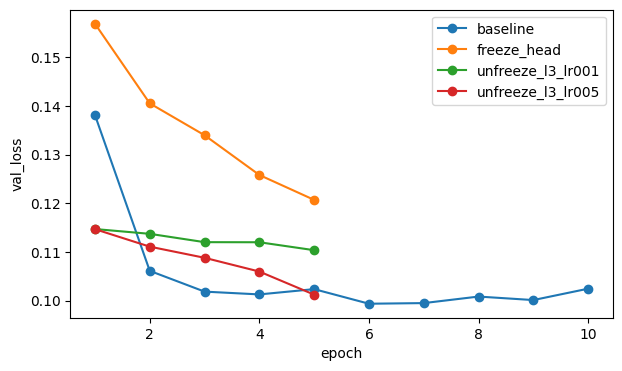

In [35]:
plt.figure(figsize=(7, 4))
for name in runs:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    plt.plot(df["epoch"], df["val_loss"], marker="o", label=name.replace("fasterrcnn_v2_", ""))
plt.xlabel("epoch")
plt.ylabel("val_loss")
plt.legend()
plt.show()

We use freeze then unfreeze, not the single-stage baseline. That baseline is only for comparison. Same lr=0.005: staged val_loss is 0.101 vs baseline 0.099. Close, and
the staged run is still falling at epoch 5. lr=0.001 was too slow

In [28]:
from helpers.utils import load_checkpoint
load_checkpoint(run_dir / "weights" / "best.pt", model)

{'epoch': 5,
 'metric': -0.10123622588859015,
 'model': OrderedDict([('backbone.body.conv1.weight',
               tensor([[[[-6.1102e-03,  9.5599e-03,  3.1568e-02,  ..., -1.4302e-01,
                           4.7951e-02,  2.8355e-02],
                         [-1.0539e-02, -7.9132e-04,  8.8673e-02,  ..., -3.3262e-01,
                           5.0684e-02,  8.0228e-02],
                         [ 5.8592e-03, -8.4502e-03,  5.4741e-02,  ..., -4.0573e-01,
                          -7.0297e-02,  1.4837e-01],
                         ...,
                         [ 4.2638e-03,  2.5437e-02, -4.4603e-02,  ..., -1.1729e-01,
                          -1.7737e-01,  1.0410e-01],
                         [-1.7198e-03, -6.8754e-04, -1.9032e-02,  ..., -3.7532e-02,
                          -7.5427e-02,  3.8558e-02],
                         [-5.2213e-03, -1.4919e-02, -1.0002e-02,  ..., -2.4140e-02,
                          -3.2910e-02, -2.3537e-03]],
               
                        [[ 1.31

In [31]:
from helpers.viz import draw_xyxy_boxes

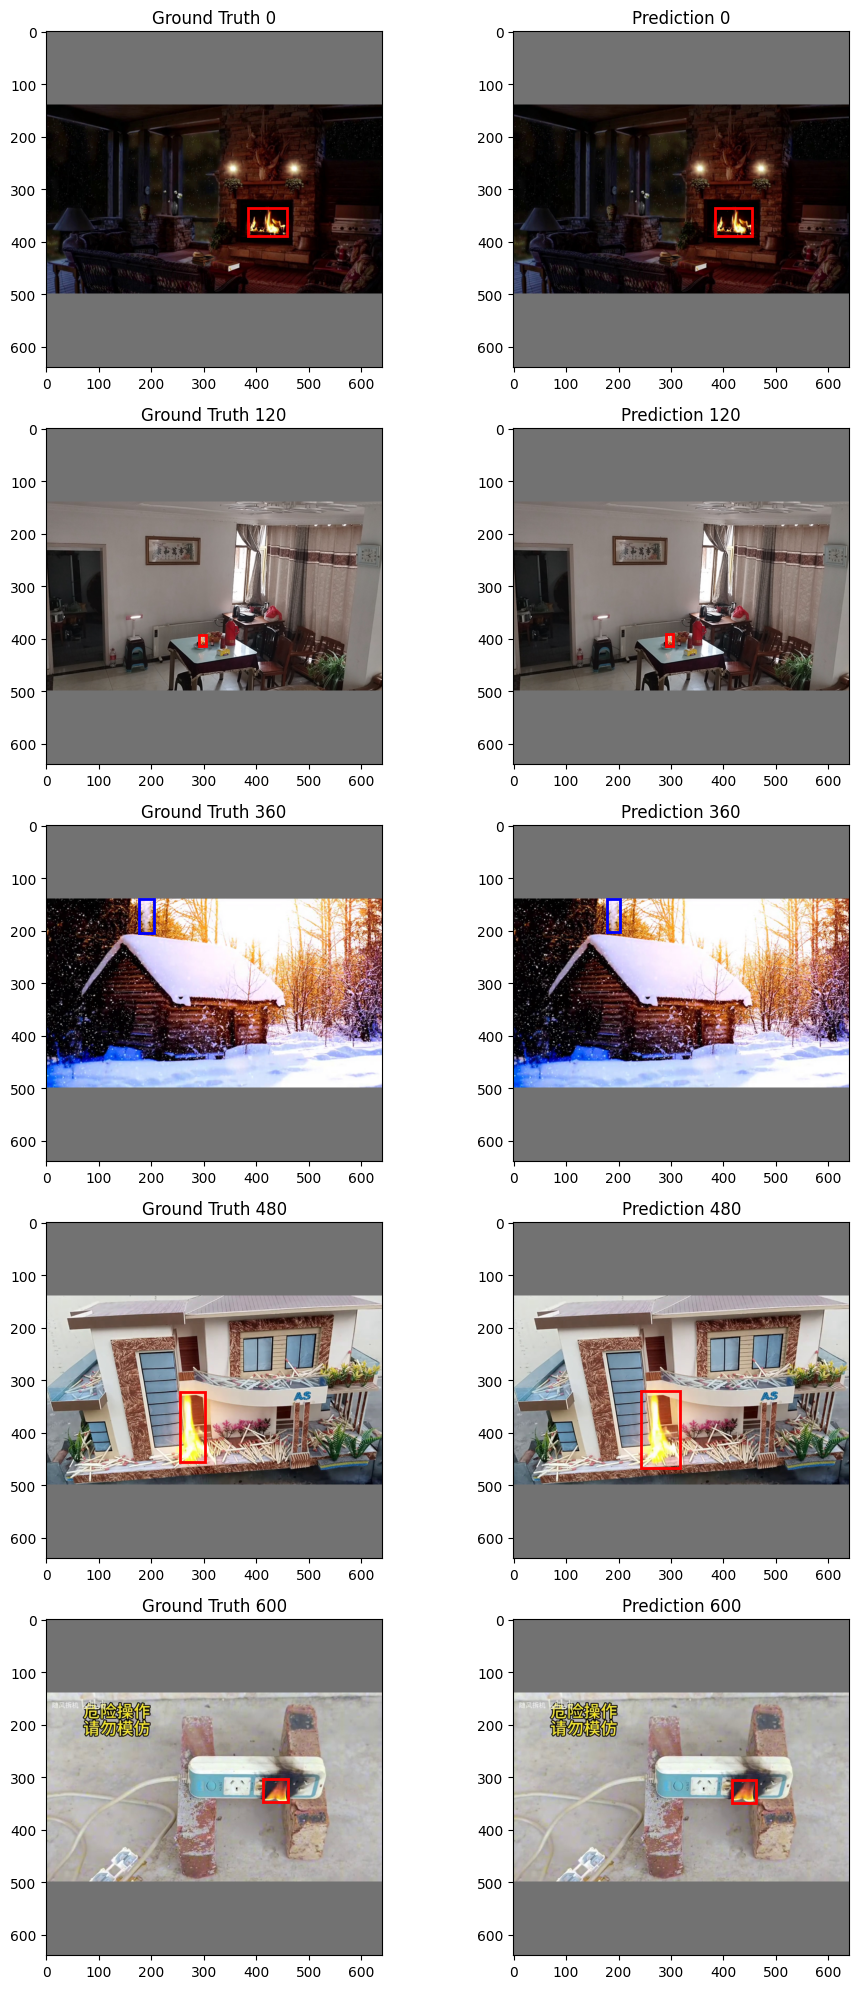

In [32]:
model.eval()
idxs = [0, 120, 360, 480, 600]
fig, axes = plt.subplots(len(idxs), 2, figsize=(10, 4 * len(idxs)))

for row, i in enumerate(idxs):
    image, target = val_ds[i]
    with torch.no_grad():
        pred = model([image.to(device)])[0]

    canvas = image.permute(1, 2, 0).cpu().numpy()

    axes[row, 0].imshow(canvas) # left: ground truth
    draw_xyxy_boxes(axes[row, 0], target["boxes"], target["labels"])
    axes[row, 0].set_title(f"Ground Truth {i}")

    axes[row, 1].imshow(canvas) # right: prediction
    draw_xyxy_boxes(axes[row, 1], pred["boxes"].cpu(), pred["labels"].cpu(), scores=pred["scores"].cpu(), conf=0.5) #matplotlib cannot use cuda tensors
    axes[row, 1].set_title(f"Prediction {i}")

plt.tight_layout()
plt.show()